In [1]:
from pathlib import Path
import importlib
import logging
import sys
import os

logging.basicConfig(
    format="%(levelname)s: %(message)s", stream=sys.stdout, level=logging.INFO
)
logger = logging.getLogger("__notebook__")

# Loading markov model directory as module into jupyter notebook
module_dir = Path(os.getcwd()).parent.resolve()
data_dir = module_dir / "data"

logger.info(f"module directory: {module_dir}")

if str(module_dir) not in sys.path:
    sys.path.insert(1, str(module_dir))
else:
    logger.info("Module path already inserted into system paths")

try:
    from model import markov_chain
    from model import probabilistic_analysis as psa
    from model import visualization
    from model import constants
    from model import utils

    # to apply changes in modules
    importlib.reload(markov_chain)
    importlib.reload(psa)
    importlib.reload(visualization)
    importlib.reload(constants)
    importlib.reload(utils)
except ModuleNotFoundError as e:
    logger.error(f"Unable to import module: {e.msg}")

INFO: module directory: /home/mohammad/projects/Thesis/hemophilia


In [6]:
# Model inputs
base_sample_size = 512  # simulated sample final count follows N * (D + 2)
long_steps = constants.LONG_TERM_CYCLE_COUNTS
ssp = constants.SHORT_SIMULATION_START_AGE_IN_WEEK  # simulation starting point

logger.info(
    f"""
    Model initialized with:
    - Base sample size: {base_sample_size}
    - Simulation steps: {long_steps} ({long_steps/constants.WOY} Years)
    - Simulation starting point: {ssp} ({ssp/constants.WOY} YO)
    """
)


# Loading states name from excel sheet is deprecated, now on only generate within the code blocks
start_state = constants.START_STATE
primary_states = constants.PRIMARY_STATES
secondary_states = constants.SECONDARY_STATES
# NOTE:
# Transition matrix is dynamically generated through the *_psa functions as they sample from abr values
# To change in states need to update the psa worker functions as well to support new model schema
# NOTE:
# Newly suggested model structure:               switch
#                   [Healthy]                    ------>                     [Arthropathy]
#        |              |              |                           |              |              |
# [LT Bleeding] | [Hemarthrosis] | [Bleeding]               [LT Bleeding] | [Hemarthrosis] | [Bleeding]
#    |                  |                                          |
# [DEATH]         [Arthropathy]                                 [DEATH]
chains = {"primary": (primary_states, {}), "secondary": (secondary_states, {})}


# Define switch conditions
def arthropathy_switch_condition(step: int, state: str, chain: str, **kwargs) -> bool:
    """Determine if a switch to the secondary chain should occur based on the Arthropathy state."""
    return state == "Arthropathy" and chain == "primary"


switch_conditions = {"secondary": arthropathy_switch_condition}

INFO: 
    Model initialized with:
    - Base sample size: 512
    - Simulation steps: 3640 (70.0 Years)
    - Simulation starting point: 104 (2.0 YO)
    


In [7]:
weights = [utils.cal_body_weight(w, b=ssp) for w in range(long_steps)]
# Short term simulation
on_demand_inputs, on_demand_outputs = psa.markov_chains_psa_wrapper(
    strategy="on_demand",
    n_samples=base_sample_size,
    chains=chains,
    start_chain="primary",
    start_state="Healthy",
    steps=long_steps,
    switch_conditions=switch_conditions,
)

prophylaxis_inputs, prophylaxis_outputs = psa.markov_chains_psa_wrapper(
    strategy="prophylaxis",
    n_samples=base_sample_size,
    chains=chains,
    start_chain="primary",
    start_state="Healthy",
    steps=long_steps,
    switch_conditions=switch_conditions,
)
# Short term simulation located at 03_*.ipynb file

In [8]:
from time import time
import pandas as pd
import numpy as np

SAMPLE_SIZE = len(on_demand_inputs)
cols = [
    "regimes",
    "abrs",
    "factors",
    "qalys",
    "costs",
    "bleeds",
    "annual_factors",
    "annual_costs",
    "is_arthropathy",
    "is_dead",
    "sequences",
    "weights",
]


def truncate_weights_at_death(sequences: list["str"]):
    death_indices = [
        i
        for i, state in enumerate(sequences)
        if state
        and any(
            "death" in str(s).lower()
            for s in (state if isinstance(state, (list, tuple)) else [state])
        )
    ]

    if death_indices:
        # Use the first death occurrence
        death_index = death_indices[0]
        return weights[: death_index + 1]  # Include the death state

    # If no death found, return full weights
    return weights


logger.info(f"{SAMPLE_SIZE:,} data generated to work with")
start = time()
od_df = pd.DataFrame(
    data={
        "regimes": "on_demand",
        "abrs": [op["abr"] for op in on_demand_inputs],
        "factors": [op.total_factor_use for op in on_demand_outputs],
        "qalys": [op.qaly for op in on_demand_outputs],
        "costs": [op.total_factor_costs for op in on_demand_outputs],
        "annual_factors": [op.annual_factor_consumption for op in on_demand_outputs],
        "annual_costs": [op.annual_factor_costs for op in on_demand_outputs],
        "is_arthropathy": [
            True if "Arthropathy" in op.sequences else False for op in on_demand_outputs
        ],
        "is_dead": [
            True if "Death" in op.sequences else False for op in on_demand_outputs
        ],
        "sequences": [op.sequences for op in on_demand_outputs],
        "weights": [
            truncate_weights_at_death(op.sequences) for op in on_demand_outputs
        ],
    },
    columns=cols,
)
od_df["mean_weight"] = od_df["weights"].apply(lambda x: np.array(x).mean())
od_df["person_year"] = od_df["weights"].apply(lambda x: len(x) / 52)
logger.info(f"Loading on_demand data with pandas took {round(time() - start, 2)} seconds")

start = time()
pro_df = pd.DataFrame(
    data={
        "regimes": "prophylaxis",
        "abrs": [op["abr"] for op in prophylaxis_inputs],
        "factors": [op.total_factor_use for op in prophylaxis_outputs],
        "qalys": [op.qaly for op in prophylaxis_outputs],
        "costs": [op.total_factor_costs for op in prophylaxis_outputs],
        "annual_factors": [op.annual_factor_consumption for op in prophylaxis_outputs],
        "annual_costs": [op.annual_factor_costs for op in prophylaxis_outputs],
        "is_arthropathy": [
            True if "Arthropathy" in op.sequences else False
            for op in prophylaxis_outputs
        ],
        "is_dead": [
            True if "Death" in op.sequences else False for op in prophylaxis_outputs
        ],
        "sequences": [op.sequences for op in prophylaxis_outputs],
        "weights": [
            truncate_weights_at_death(op.sequences) for op in prophylaxis_outputs
        ],
    },
    columns=cols,
)
pro_df["mean_weight"] = pro_df["weights"].apply(lambda x: np.array(x).mean())
pro_df["person_year"] = pro_df["weights"].apply(lambda x: round(len(x) / 52, 2))
logger.info(f"loading prophylaxis data with pandas took {round(time() - start, 2)} seconds")

df = pd.concat([od_df, pro_df])

INFO: 11,264 data generated to work with


INFO: Loading on_demand data with pandas took 46.34 seconds
INFO: loading prophylaxis data with pandas took 46.25 seconds


INFO: Patients average weight: 66.9 kg


Text(0.5, 0, 'Age (year)')

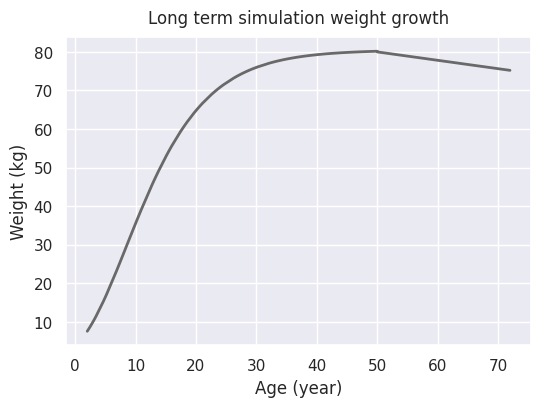

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pairs: dict[int, float] = {(i + ssp): weight for i, weight in enumerate(weights)}
average_weight = np.mean(list(pairs.values()))

logger.info(f"Patients average weight: {round(average_weight, 2)} kg")

# Drawing patient weight growth plot
sns.set_theme()
fig, ax = plt.subplots(1, 1, figsize=(6, 4))
X = np.array(list(pairs.keys()))
Y = np.array(list(pairs.values()))
ax.plot(X / constants.WOY, Y, color='dimgray', linestyle='-', linewidth=2)
ax.set_title("Long term simulation weight growth", pad=10)
ax.set_ylabel("Weight (kg)")
ax.set_xlabel("Age (year)")

In [126]:
# ---- Debug cell ----
debug = False

# Graphs stores at outputs/figures/transitions
if debug:
    # on_demand simulation transition matrix graph
    for rate, inputs in enumerate(np.random.choice(on_demand_inputs, size=5)):
        chains = inputs["chains"]
        primary_matrix = chains["primary"][1]
        secondary_matrix = chains["secondary"][1]
        visualization.visualize_transition_matrix(
            matrix=primary_matrix,
            states=primary_states,
            title=f"on-demand-primary-{int(round(inputs['abr'],0))}-{int(round(inputs['ajbr'], 0))}",
        )
        visualization.visualize_transition_matrix(
            matrix=secondary_matrix,
            states=secondary_states,
            title=f"on-demand-secondary-{int(round(inputs['abr'],0))}-{int(round(inputs['ajbr'], 0))}",
        )
    # prophylaxis simulation transition matrix graph
    for rate, inputs in enumerate(np.random.choice(prophylaxis_inputs, size=5)):
        chains = inputs["chains"]
        primary_matrix = chains["primary"][1]
        secondary_matrix = chains["secondary"][1]
        visualization.visualize_transition_matrix(
            matrix=primary_matrix,
            states=primary_states,
            title=f"prophylaxis-primary-{int(round(inputs['abr'],0))}-{int(round(inputs['ajbr'], 0))}",
        )
        visualization.visualize_transition_matrix(
            matrix=secondary_matrix,
            states=secondary_states,
            title=f"prophylaxis-secondary-{int(round(inputs['abr'],0))}-{int(round(inputs['ajbr'], 0))}",
        )

In [ ]:
# Value to report:
# Report no. of factor viii infusions [ ]
# Report annual cost of factor viii / kg [ ]
# Report annual joint hemorrhages [ ]
# Budget impact [ }
# Burden of disease [√]
# Report no. of factor viii unit infused [√]
# Report no. of factor viii unit infused per kg [√]
# Report annual bleeding rate [√]
# Report quality adjusted life year [√]
# Report Incremental cost effectiveness ratio [√]
# Report Net monetary benefit [√]

In [10]:
SIM_YEARS = int(long_steps / constants.WOY)
DC = round((pro_df["costs"].mean() - od_df["costs"].mean()), 2)  # per patient
DQ = round((pro_df["qalys"].mean() - od_df["qalys"].mean()), 2)  # per patient
DC_TOTAL = round(pro_df["costs"].sum() - od_df["costs"].sum(), 2)
DQ_TOTAL = round(pro_df["qalys"].sum() - od_df["qalys"].sum(), 2)
# annual costs gained per patient
DC_ANNUAL = round(DC / (long_steps / constants.WOY), 2)
ICER = DC_TOTAL / DQ_TOTAL
ICER_ANNUAL = round(ICER / (long_steps / constants.WOY), 2)
LYG_TOTAL = round(pro_df["person_year"].sum() - od_df["person_year"].sum(), 2)
ICER_LTG = DC_TOTAL / LYG_TOTAL


# Net monetary benefits
NMB = round((constants.WTP_THRESHOLD *  SIM_YEARS * (DQ)) - (DC), 2)
# TODO:
# - Number of died patients are not rational, tune the model with accurate rate
# - Make sure the transitioning probability to arthropathy is valid
logger.info(
    f"""
    [Short Term]
    Simulation results for {int(long_steps/constants.WOY)} Years ({int(ssp/52)} - {int((ssp + long_steps)/52)}) | {SAMPLE_SIZE} samples included
    Number of simulations transitioned to chronic arthropathy: -> On Demand: {od_df["is_arthropathy"].sum()} - Prophylaxis: {pro_df["is_arthropathy"].sum()}
    Percentage of normal joints: On Demand: -> {round(1 - (od_df['is_arthropathy'].sum()/SAMPLE_SIZE), 2)}% - Prophylaxis: {round(1 - (pro_df['is_arthropathy'].sum()/SAMPLE_SIZE), 2)}%
    Number of patients died from life threating bleedings: -> On Demand: {od_df["is_dead"].sum()} - Prophylaxis: {pro_df['is_dead'].sum()}
    Mortality rate (deaths per 100 person-years): -> On Demand: {round(od_df["is_dead"].sum()/od_df['person_year'].sum() * 100, 2)} - Prophylaxis: {round(pro_df['is_dead'].sum()/pro_df['person_year'].sum() * 100, 2)}
    Life year gained: {LYG_TOTAL} years, per person {round(LYG_TOTAL / SAMPLE_SIZE, 2)} years
    
    [Model outputs]
    Annual bleeding rate:
    - On Demand: Mean (std) {int(od_df['abrs'].mean())} ({int(od_df['abrs'].std())}), Median {int(od_df['abrs'].median())}
    - Prophylaxis : Mean (std) {int(pro_df['abrs'].mean())} ({int(pro_df['abrs'].std())}), Median {int(pro_df['abrs'].median())}
    Note: prophylaxis on average reduces ABR about {1 - round(od_df['abrs'].mean()/ pro_df['abrs'].mean()/100, 2)}%
    
    Total factor consumption:
    - On Demand: {int(od_df['factors'].mean())} ({int(od_df['factors'].std())}) IU
    - Prophylaxis: {int(pro_df['factors'].mean())} ({int(pro_df['factors'].std())}) IU
    Note: consumptions increased by {round(pro_df['factors'].mean() / od_df['factors'].mean(), 2)} folds
    
    Annual factor consumption:
    - On Demand: {int(od_df['annual_factors'].mean())} ({int(od_df['annual_factors'].std())}) IU
    - Prophylaxis: {int(pro_df['annual_factors'].mean())} ({int(pro_df['annual_factors'].std())}) IU
    
    Annual factor consumption per kg:
    - On Demand: {int(od_df['annual_factors'].mean() / od_df['mean_weight'].mean())} IU
    - Prophylaxis: {int(pro_df['annual_factors'].mean() / pro_df['mean_weight'].mean())} IU
    
    Annual factor costs per kg:
    - On Demand: ${int(od_df['annual_costs'].mean() / od_df['mean_weight'].mean()):,}
    - Prophylaxis: ${int(pro_df['annual_costs'].mean() / pro_df['mean_weight'].mean()):,}
    
    Annual burden of disease for {SAMPLE_SIZE} patients (Factor VIII only):
    - On Demand: ${int(od_df['annual_costs'].sum()):,}
    - Prophylaxis: ${int(pro_df['annual_costs'].sum()):,}
    
    Quality adjusted life year:
    - On Demand: Mean (std) {round(od_df['qalys'].mean(), 2)}, ({round(od_df['qalys'].std(), 2)}), Median {round(od_df['qalys'].median(), 2)}
    - Prophylaxis: Mean (std) {round(pro_df['qalys'].mean(), 2)}, ({round(pro_df['qalys'].std(), 2)}) | Median {round(pro_df['qalys'].median(), 2)}
    
    Conclusions:
    {DQ} qaly gained with ${DC:,} increase in cost of treatment
    Incremental cost effectiveness ratio: ${int(ICER):,} | ICER LYG: ${int(ICER_LTG):,}
    Willingness to pay threshold: ${round(constants.WTP_THRESHOLD, 2):,} {'>' if constants.WTP_THRESHOLD > ICER_ANNUAL else '<'} ${ICER_ANNUAL:,}
    Net monetary benefit: ${int(NMB):,}
    
    CUA: Intervention {'was' if NMB > 0 else 'was not'} cost effective
    """
)

INFO: 
    [Short Term]
    Simulation results for 70 Years (2 - 72) | 11264 samples included
    Number of simulations transitioned to chronic arthropathy: -> On Demand: 8021 - Prophylaxis: 2868
    Percentage of normal joints: On Demand: -> 0.29% - Prophylaxis: 0.75%
    Number of patients died from life threating bleedings: -> On Demand: 9030 - Prophylaxis: 4044
    Mortality rate (deaths per 100 person-years): -> On Demand: 2.62 - Prophylaxis: 0.65
    Life year gained: 278469.68 years, per person 24.72 years
    
    [Model outputs]
    Annual bleeding rate:
    - On Demand: Mean (std) 21 (20), Median 14
    - Prophylaxis : Mean (std) 3 (4), Median 1
    Note: prophylaxis on average reduces ABR about 0.94%
    
    Total factor consumption:
    - On Demand: 1617137 (1907082) IU
    - Prophylaxis: 14735931 (6829165) IU
    Note: consumptions increased by 9.11 folds
    
    Annual factor consumption:
    - On Demand: 23101 (27244) IU
    - Prophylaxis: 210513 (97559) IU
    
    An

In [ ]:
# TODO:
# Incremental costs . Incremental qalys
# Tornado diagram

INFO: 
    Bootstrapping model outputs to calculate ICER IQR and SD
    
INFO: Bootstrapping with 5000 iterations took 19.47 seconds
INFO: 
    IQR: $2837.67
    


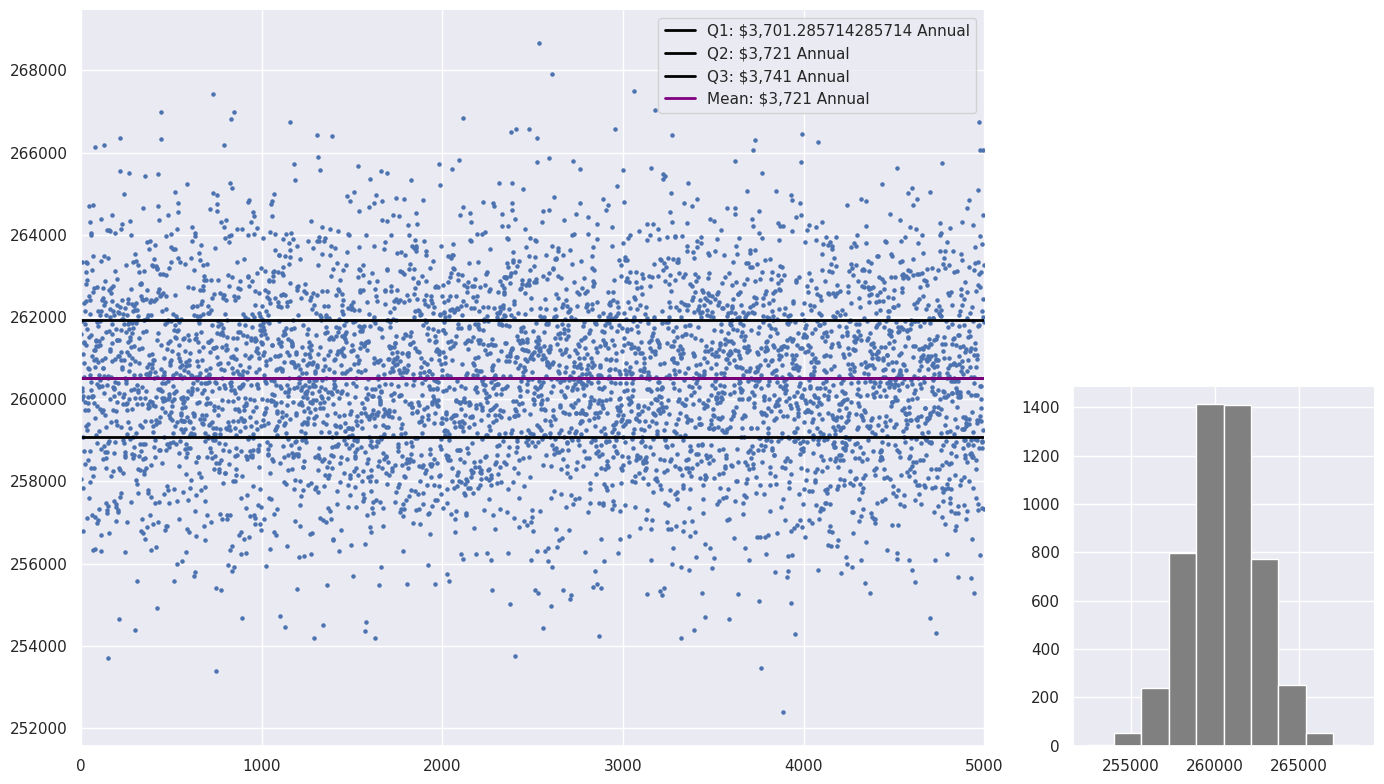

In [18]:
from matplotlib.gridspec import GridSpec
logger.info(
    """
    Bootstrapping model outputs to calculate ICER IQR and SD
    """
)
ICERS = []
BOOTS_ITER = 5000
start = time()
for th in range(BOOTS_ITER):
    od = od_df.sample(n=SAMPLE_SIZE, replace=True)
    pro = pro_df.sample(n=SAMPLE_SIZE, replace=True)
    dc = pro["costs"].sum() - od["costs"].sum()
    dq = pro["qalys"].sum() - od["qalys"].sum()
    if np.isfinite(dc) and np.isfinite(dq) and dq != 0:
        ICERS.append(dc / dq)
logger.info(
    f"Bootstrapping with {BOOTS_ITER} iterations took {round(time() - start, 2)} seconds"
)

ICERS = np.array(ICERS)
pairs = {i: y for i, y in enumerate(ICERS)}
X = list(pairs.keys())
Y = list(pairs.values())

fig = plt.figure(figsize=(14, 8))

gs = GridSpec(2, 2, width_ratios=(3, 1), height_ratios=(1, 1))
ax1 = fig.add_subplot(gs[: , :-1])
ax2 = fig.add_subplot(gs[-1, -1])
ax1.scatter(X, Y, s=5)
ax2.hist(Y, color='gray')


Q1 = np.percentile(ICERS, 25).astype(float)
Q2 = np.percentile(ICERS, 50).astype(float)
Q3 = np.percentile(ICERS, 75).astype(float)
ICERS_MEAN = ICERS.mean()

ax1.axhline(Q1, color="black", linewidth=2, label=f"Q1: ${int(Q1)/ SIM_YEARS:,} Annual")
ax1.axhline(Q2, color="black", linewidth=2, label=f"Q2: ${int(Q2/ SIM_YEARS):,} Annual")
ax1.axhline(Q3, color="black", linewidth=2, label=f"Q3: ${int(Q3/ SIM_YEARS):,} Annual")
ax1.axhline(
    ICERS_MEAN, color="purple", linewidth=2, label=f"Mean: ${int(ICERS_MEAN / SIM_YEARS):,} Annual"
)
ax1.set_xlim(left=0, right=ICERS.shape[0])
ax1.legend()
fig.tight_layout()

logger.info(
    f"""
    IQR: ${(Q3 - Q1):.2f}
    """
)

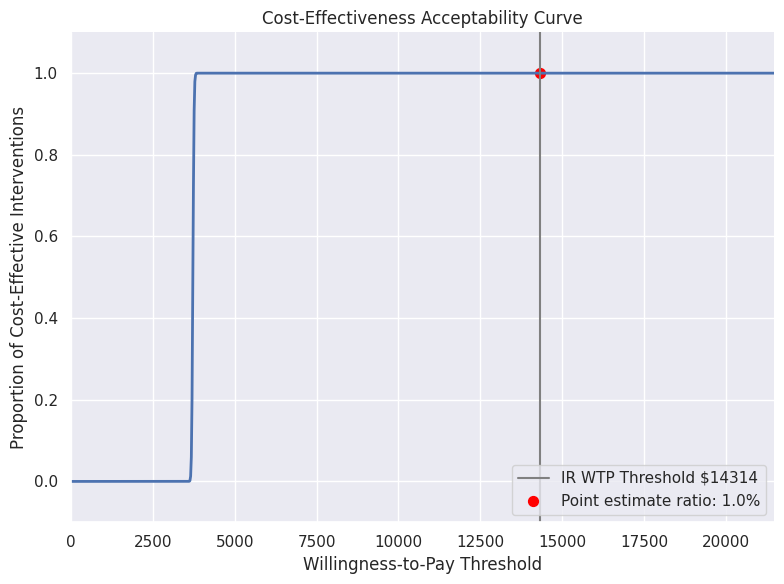

In [26]:
# Create WTP thresholds - consider making the upper bound more flexible
max_threshold = constants.WTP_THRESHOLD * 1.5
X = np.linspace(start=0, stop=max_threshold, num=1000)

Y = []
for threshold in X:
    # Below the current threshold
    cost_effective_count = np.sum(ICERS / SIM_YEARS <= threshold) # type: ignore
    ratio = cost_effective_count / len(ICERS)
    Y.append(ratio)
icer_ratio = np.sum(ICERS / SIM_YEARS <= constants.WTP_THRESHOLD) / len(ICERS) # type: ignore
# Create the plot
fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(X, Y, linewidth=2)
ax.axvline(x=constants.WTP_THRESHOLD, color='gray', label=f"IR WTP Threshold ${int(constants.WTP_THRESHOLD)}")
ax.scatter(x=constants.WTP_THRESHOLD, y=icer_ratio, color='red', s=50, label=f"Point estimate ratio: {round(icer_ratio, 4)}%")
ax.set_xlabel('Willingness-to-Pay Threshold')
ax.set_ylabel('Proportion of Cost-Effective Interventions')
ax.set_title('Cost-Effectiveness Acceptability Curve')
ax.set_xlim(0, max_threshold)
ax.set_ylim(-0.1, 1.1)
ax.legend()
fig.tight_layout()

INFO: ICER calculation took: 0.0 seconds


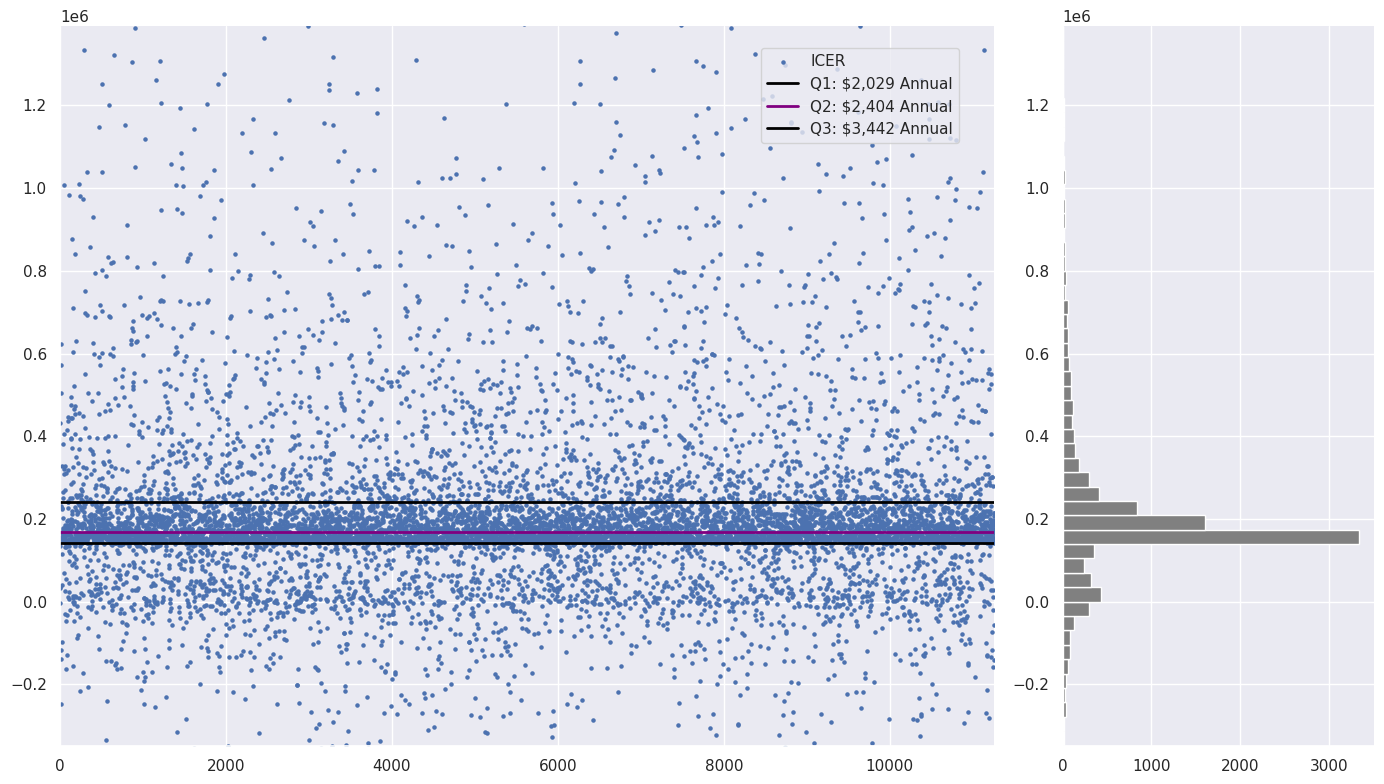

In [27]:
sns.set_theme(style="darkgrid", rc={"axes.spines.right": False, "axes.spines.top": False})
start = time()
dc = pro_df["costs"].to_numpy() - od_df["costs"].to_numpy()
dq = pro_df["qalys"].to_numpy() - od_df["qalys"].to_numpy()

valid_mask = np.isfinite(dq) & np.isfinite(dc) & (dq != 0)

ICERS = dc[valid_mask] / dq[valid_mask]

logger.info(f"ICER calculation took: {round(time() - start, 2)} seconds")

fig = plt.figure(figsize=(14, 8))
gs = GridSpec(2, 2, width_ratios=(3, 1), height_ratios=(1, 1))

ax1 = fig.add_subplot(gs[:, :-1])
ax2 = fig.add_subplot(gs[:, -1])

ax1.scatter(x=[i for i in range(ICERS.shape[0])], y=ICERS, s=5)

Q1 = np.percentile(ICERS, 25).astype(float)
Q2 = np.percentile(ICERS, 50).astype(float)
Q3 = np.percentile(ICERS, 75).astype(float)

P5 = np.percentile(ICERS, 5).astype(float)
P95 = np.percentile(ICERS, 95).astype(float)
TRUNC_ICERS = ICERS[(ICERS >= P5) & (ICERS <= P95)]
ax2.hist(TRUNC_ICERS, bins=50, color="gray", orientation="horizontal")
ax2.set_ylim(bottom=P5, top=P95)

ax1.axhline(
    Q1,
    color="black",
    linewidth=2,
)
ax1.axhline(
    Q2,
    color="purple",
    linewidth=2,
)
ax1.axhline(Q3, color="black", linewidth=2)
ax1.set_xlim(left=0, right=ICERS.shape[0])
ax1.set_ylim(bottom=P5, top=P95)
fig.legend(
    [
        "ICER",
        f"Q1: ${int(Q1 / SIM_YEARS):,} Annual",
        f"Q2: ${int(Q2 / SIM_YEARS):,} Annual",
        f"Q3: ${int(Q3 / SIM_YEARS):,} Annual",
    ],
    loc="upper center",
    bbox_to_anchor=(0.62, 0.94),
)
fig.tight_layout()

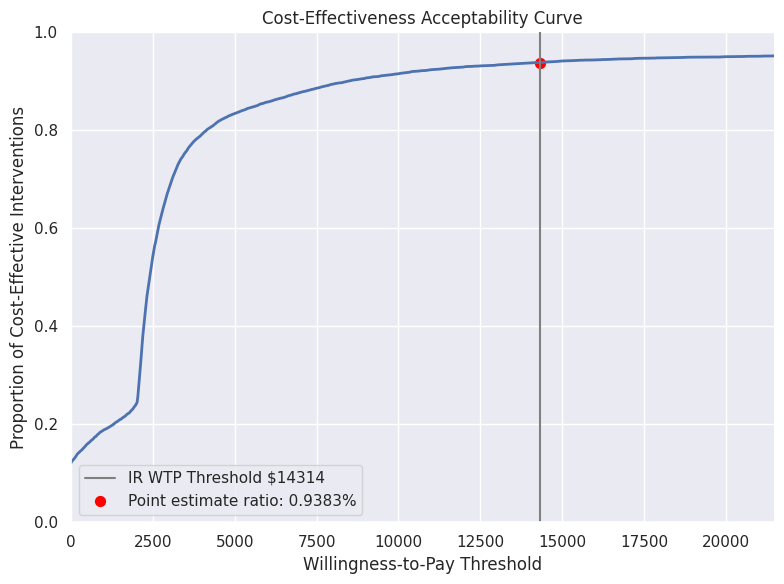

In [28]:
# Create WTP thresholds - consider making the upper bound more flexible
max_threshold = constants.WTP_THRESHOLD * 1.5
X = np.linspace(start=0, stop=max_threshold, num=1000)

Y = []
for threshold in X:
    # Below the current threshold
    cost_effective_count = np.sum(ICERS / SIM_YEARS <= threshold)
    ratio = cost_effective_count / len(ICERS)
    Y.append(ratio)
icer_ratio = np.sum(ICERS / SIM_YEARS <= constants.WTP_THRESHOLD) / len(ICERS)
# Create the plot
fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(X, Y, linewidth=2)
ax.axvline(x=constants.WTP_THRESHOLD, color='gray', label=f"IR WTP Threshold ${int(constants.WTP_THRESHOLD)}")
ax.scatter(x=constants.WTP_THRESHOLD, y=icer_ratio, color='red', s=50, label=f"Point estimate ratio: {round(icer_ratio, 4)}%")
ax.set_xlabel('Willingness-to-Pay Threshold')
ax.set_ylabel('Proportion of Cost-Effective Interventions')
ax.set_title('Cost-Effectiveness Acceptability Curve')
ax.set_xlim(0, max_threshold)
ax.set_ylim(0, 1)
ax.legend()
fig.tight_layout()